# Load HRRR data

In [26]:
import requests
import pandas as pd
import time


LAT = 30.110600
LON = -95.437168

URL = "https://single-runs-api.open-meteo.com/v1/forecast"


def get_hrrr_runs(start_date, end_date):
    """
    Retrieve archived HRRR 15-minute forecasts from Open-Meteo.

    Parameters
    ----------
    start_date : str
        Start date, e.g. "2026-05-01"

    end_date : str
        End date, e.g. "2026-05-03"

    Returns
    -------
    pandas.DataFrame
        One row per forecast timestep and model run.
    """

    # HRRR archived runs appear to be available every 3 hours
    runs = pd.date_range(
        start=start_date,
        end=end_date,
        freq="3h",
        tz="UTC"
    )

    all_runs = []

    for run_time in runs:

        run_str = run_time.strftime("%Y-%m-%dT%H:%M")

        print(f"Fetching HRRR run: {run_str}")

        params = {
            "latitude": LAT,
            "longitude": LON,

            "models": "ncep_hrrr_conus",

            "run": run_str,

            "minutely_15": ",".join([
                "precipitation",
                "rain",
                "temperature_2m",
                "relative_humidity_2m",
                "wind_speed_10m",
                "wind_direction_10m",
                "wind_gusts_10m",
            ]),

            # Number of 15-minute forecast timesteps
            "forecast_minutely_15": 72,

            # Keep everything in UTC
            "timezone": "UTC",
        }

        response = requests.get(
            URL,
            params=params,
            timeout=60
        )

        # Handle unavailable runs
        if response.status_code != 200:
            print(
                f"  WARNING: run {run_str} unavailable "
                f"({response.status_code})"
            )
            continue

        data = response.json()

        # Convert response to DataFrame
        df = pd.DataFrame(data["minutely_15"])

        # Parse forecast valid time
        df["valid_time"] = pd.to_datetime(
            df["time"],
            utc=True
        )

        df.drop(columns=["time"], inplace=True)

        # Add model initialization time
        df["run_time"] = run_time

        # Calculate forecast lead time
        df["lead_time_minutes"] = (
            df["valid_time"] - df["run_time"]
        ).dt.total_seconds() / 60

        df["lead_time_hours"] = (
            df["lead_time_minutes"] / 60
        )

        # Put identifiers first
        cols = [
            "run_time",
            "valid_time",
            "lead_time_minutes",
            "lead_time_hours",
        ]

        other_cols = [
            c for c in df.columns
            if c not in cols
        ]

        df = df[cols + other_cols]

        all_runs.append(df)

        # Be polite to the API
        time.sleep(0.2)

    if not all_runs:
        raise RuntimeError("No HRRR runs were successfully retrieved.")

    # Combine all runs
    result = pd.concat(
        all_runs,
        ignore_index=True
    )

    # Sort chronologically
    result = result.sort_values(
        ["valid_time", "run_time"]
    ).reset_index(drop=True)

    return result

In [27]:
hrrr = get_hrrr_runs(
    "2026-05-01",
    "2026-05-03"
)

print(hrrr.head(20))
print(hrrr.shape)

Fetching HRRR run: 2026-05-01T00:00
Fetching HRRR run: 2026-05-01T03:00
Fetching HRRR run: 2026-05-01T06:00
Fetching HRRR run: 2026-05-01T09:00
Fetching HRRR run: 2026-05-01T12:00
Fetching HRRR run: 2026-05-01T15:00
Fetching HRRR run: 2026-05-01T18:00
Fetching HRRR run: 2026-05-01T21:00
Fetching HRRR run: 2026-05-02T00:00
Fetching HRRR run: 2026-05-02T03:00
Fetching HRRR run: 2026-05-02T06:00
Fetching HRRR run: 2026-05-02T09:00
Fetching HRRR run: 2026-05-02T12:00
Fetching HRRR run: 2026-05-02T15:00
Fetching HRRR run: 2026-05-02T18:00
Fetching HRRR run: 2026-05-02T21:00
Fetching HRRR run: 2026-05-03T00:00
                    run_time                valid_time  lead_time_minutes  \
0  2026-05-01 00:00:00+00:00 2026-05-01 00:00:00+00:00                0.0   
1  2026-05-01 00:00:00+00:00 2026-05-01 00:15:00+00:00               15.0   
2  2026-05-01 00:00:00+00:00 2026-05-01 00:30:00+00:00               30.0   
3  2026-05-01 00:00:00+00:00 2026-05-01 00:45:00+00:00               45.0   
4  

In [41]:
# Run times
hrrr_run_times = hrrr["run_time"].unique()

In [46]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Temperature (C)')

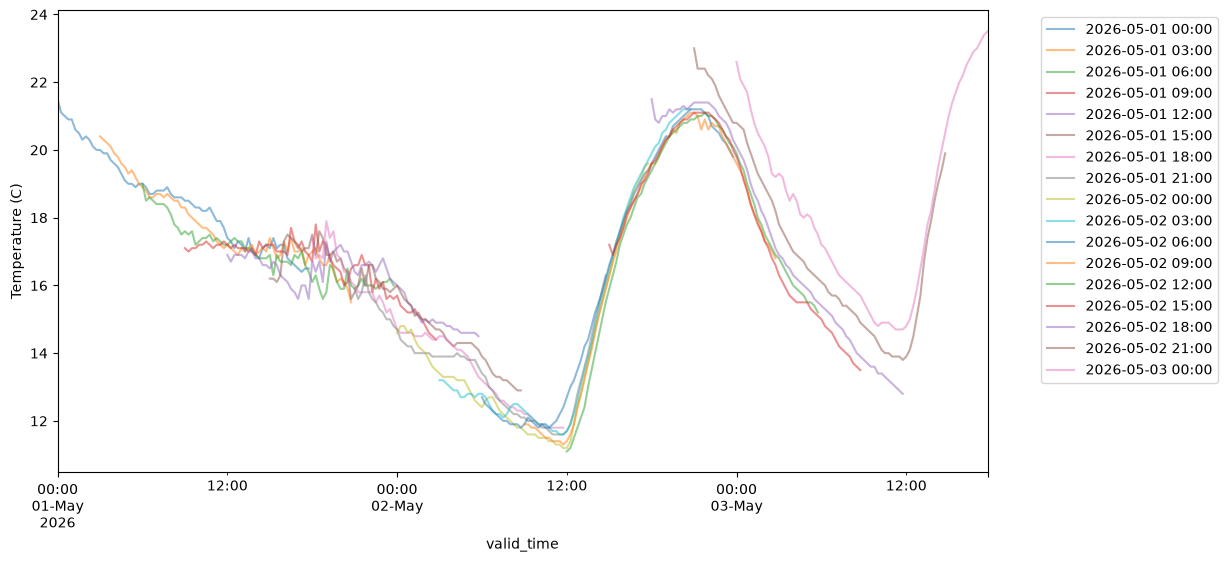

In [60]:
fig,ax = plt.subplots(figsize=(12,6))
for uq in hrrr_run_times:
    hrrr[hrrr['run_time'] == uq].plot(x='valid_time', y='temperature_2m', linewidth=1.5, alpha = 0.5,ax=ax,label=uq.strftime("%Y-%m-%d %H:%M"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("Temperature (C)")

<Axes: >

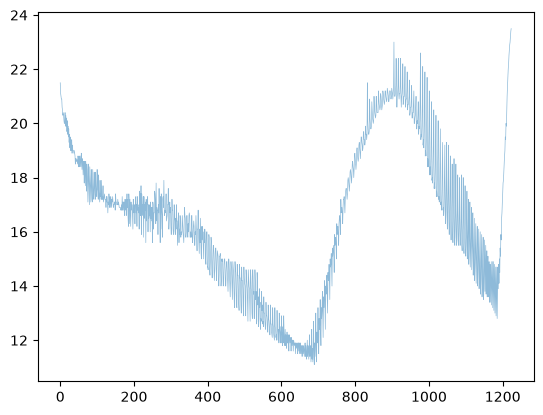

In [59]:
hrrr['temperature_2m'].plot(linewidth=0.5, alpha = 0.5) # This shows the range of prediction 


<Axes: >

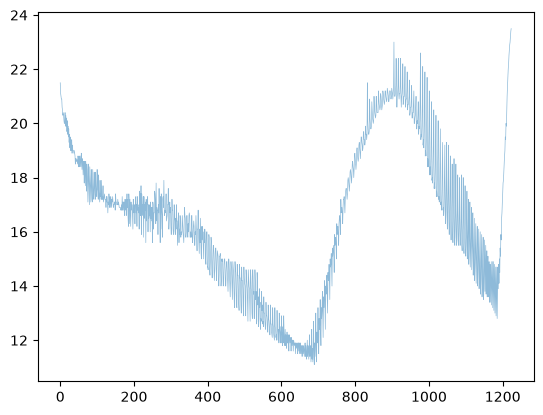